# Project 4 — Anomaly Detection in Real Data

Anomaly detection is used when unusual cases are rare, diverse, and often more important than common cases. Unlike ordinary classification, we may have few or no labeled anomalies during training, and the final decision depends heavily on threshold choice.

This notebook uses a controlled anomaly-detection setup with real data: the sklearn Digits dataset. We treat digit `9` as the anomaly class and the remaining digits as normal. This is not the same as real fraud or intrusion detection, but it provides a stable benchmark for learning the workflow.

## Prerequisites

The notebook assumes basic knowledge of precision, recall, F1-score, ROC-AUC, PR-AUC, feature scaling, and distance-based learning. The autoencoder section uses a small neural network and is optional if TensorFlow/Keras is unavailable.

## Problem statement

Given mostly normal samples and a small number of abnormal samples, identify anomalies without relying on standard balanced supervised classification assumptions.

The notebook emphasizes novelty detection: models are trained mainly on normal data and evaluated on a test set containing both normal and anomaly samples.

In [1]:
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

In [2]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, precision_recall_curve
)
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

digits = load_digits()
X = digits.data
y_digit = digits.target
images = digits.images

ANOMALY_DIGIT = 9
y = (y_digit == ANOMALY_DIGIT).astype(int)  # normal=0, anomaly=1

print("Dataset shape:", X.shape)
print("Anomaly digit:", ANOMALY_DIGIT)
display(pd.Series(y).map({0: "normal", 1: "anomaly"}).value_counts())

Dataset shape: (1797, 64)
Anomaly digit: 9


normal     1617
anomaly     180
dtype: int64

## Creating the anomaly-detection setup

We construct binary labels: normal samples are digits other than 9, and anomalies are digit 9. The training set for novelty detection contains only normal samples. The test set contains both normal and anomaly samples.

This mirrors a common real-world situation: many normal examples are available, while future abnormal cases may be rare or unknown.

In [3]:
X_train_all, X_test, y_train_all, y_test, digit_train_all, digit_test = train_test_split(
    X, y, y_digit, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

X_train_normal = X_train_all[y_train_all == 0]

scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)
X_train_all_scaled = scaler.transform(X_train_all)

print("Normal-only training shape:", X_train_normal_scaled.shape)
print("Test shape:", X_test_scaled.shape)
display(pd.Series(y_test).map({0: "normal", 1: "anomaly"}).value_counts())

Normal-only training shape: (1131, 64)
Test shape: (540, 64)


normal     486
anomaly     54
dtype: int64

## EDA: visual check of normal and anomaly samples

EDA cannot solve anomaly detection, but it can reveal whether anomalies are visually distinct or overlapping with normal cases. Here, digit 9 can look similar to some normal digits such as 4 or 7, which makes the problem more realistic than a perfectly separable setup.

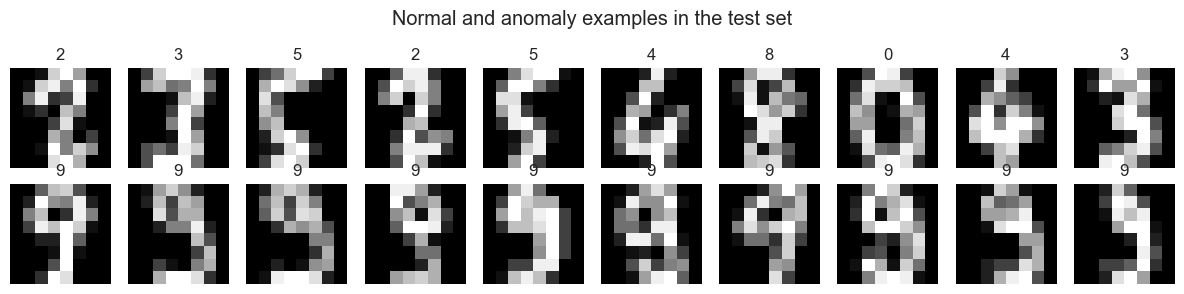

In [4]:
normal_examples = np.where((y_test == 0))[0][:10]
anomaly_examples = np.where((y_test == 1))[0][:10]

fig, axes = plt.subplots(2, 10, figsize=(12, 3))

for j, idx in enumerate(normal_examples):
    axes[0, j].imshow(X_test[idx].reshape(8, 8), cmap="gray")
    axes[0, j].set_title(str(digit_test[idx]))
    axes[0, j].axis("off")

for j, idx in enumerate(anomaly_examples):
    axes[1, j].imshow(X_test[idx].reshape(8, 8), cmap="gray")
    axes[1, j].set_title(str(digit_test[idx]))
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("Normal")
axes[1, 0].set_ylabel("Anomaly")
plt.suptitle("Normal and anomaly examples in the test set")
plt.tight_layout()
plt.show()

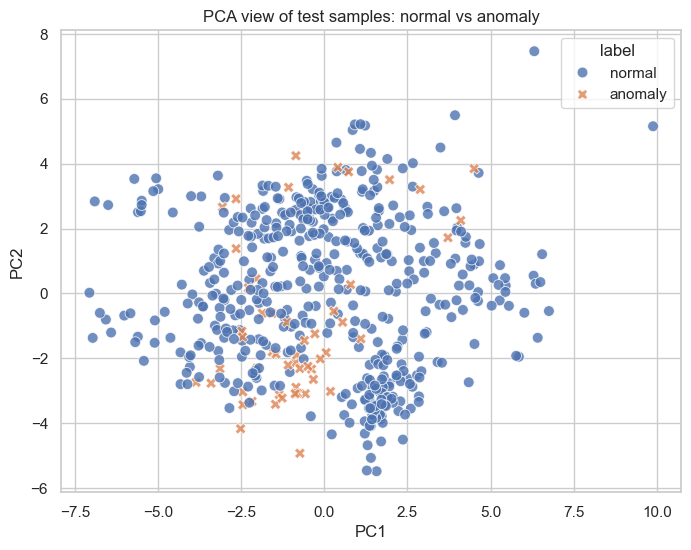

In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_test_pca = pca.fit_transform(X_test_scaled)

eda_df = pd.DataFrame(X_test_pca, columns=["PC1", "PC2"])
eda_df["label"] = np.where(y_test == 1, "anomaly", "normal")
eda_df["digit"] = digit_test

plt.figure(figsize=(8, 6))
sns.scatterplot(data=eda_df, x="PC1", y="PC2", hue="label", style="label", s=60, alpha=0.8)
plt.title("PCA view of test samples: normal vs anomaly")
plt.show()

## Evaluation metrics for anomaly detection

Accuracy is misleading when anomalies are rare. A model that predicts everything as normal can appear accurate while missing all anomalies.

We use:

- **Precision**: among flagged anomalies, how many are truly anomalous?
- **Recall**: among true anomalies, how many are detected?
- **F1-score**: harmonic mean of precision and recall.
- **ROC-AUC**: ranking quality across thresholds.
- **PR-AUC**: especially informative under class imbalance.
- **Precision at top-k**: how many true anomalies appear among the most suspicious cases?

Most detectors output an anomaly score. A threshold converts that score into binary predictions.

In [6]:
def evaluate_binary(y_true, y_pred, scores=None, name="model"):
    result = {
        "method": name,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if scores is not None:
        result["ROC_AUC"] = roc_auc_score(y_true, scores)
        result["PR_AUC"] = average_precision_score(y_true, scores)
    return result

def predict_by_top_fraction(scores, fraction):
    n_flag = max(1, int(np.ceil(len(scores) * fraction)))
    threshold = np.sort(scores)[-n_flag]
    return (scores >= threshold).astype(int), threshold

def precision_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1][:k]
    return y_true[order].mean()

def recall_at_fixed_precision(y_true, scores, target_precision=0.80):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    valid = precision >= target_precision
    if not np.any(valid):
        return np.nan
    return np.max(recall[valid])

### A baseline that predicts everything as normal

Before using anomaly detectors, it is useful to see how misleading accuracy can be. In a rare-event setup, a model can obtain high accuracy simply by predicting the majority class. The following baseline deliberately does that, so later methods should be judged mainly by precision, recall, F1, PR-AUC, and the practical alert budget rather than raw accuracy.

In [9]:
all_normal_pred = np.zeros_like(y_test)
all_normal_metrics = evaluate_binary(
    y_test,
    all_normal_pred,
    scores=np.zeros_like(y_test, dtype=float),
    name="all-normal baseline"
)

all_normal_df = pd.DataFrame([all_normal_metrics])
numeric_cols = all_normal_df.select_dtypes(include="number").columns
all_normal_df[numeric_cols] = all_normal_df[numeric_cols].round(4)

display(all_normal_df)

,method,precision,recall,f1,ROC_AUC,PR_AUC
0,all-normal baseline,0.0,0.0,0.0,0.5,0.1


This baseline usually has high accuracy when anomalies are rare, but zero recall for anomalies.

## Statistical baseline: z-score anomaly score

A simple baseline is to flag samples with extreme standardized feature values. This works when anomalies are univariate extremes, but it can fail when anomalies are subtle combinations of otherwise normal feature values.

We compute a z-score-like anomaly score using the normal training distribution.

In [10]:
normal_mean = X_train_normal_scaled.mean(axis=0)
normal_std = X_train_normal_scaled.std(axis=0) + 1e-8

z_abs = np.abs((X_test_scaled - normal_mean) / normal_std)
z_score = z_abs.max(axis=1)

z_rows = []
for threshold in [2.0, 2.5, 3.0, 3.5, 4.0]:
    pred = (z_score >= threshold).astype(int)
    z_rows.append({
        "threshold": threshold,
        **evaluate_binary(y_test, pred, z_score, name="z-score")
    })

z_df = pd.DataFrame(z_rows)
z_df

,threshold,method,precision,recall,f1,ROC_AUC,PR_AUC
0,2.0,z-score,0.107784,0.666667,0.185567,0.494627,0.097937
1,2.5,z-score,0.075000,0.333333,0.122449,0.494627,0.097937
2,3.0,z-score,0.080537,0.222222,0.118227,0.494627,0.097937
3,3.5,z-score,0.082474,0.148148,0.105960,0.494627,0.097937
4,4.0,z-score,0.084507,0.111111,0.096000,0.494627,0.097937


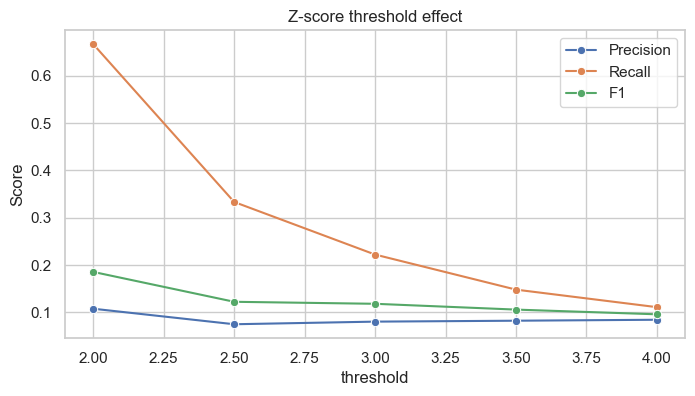

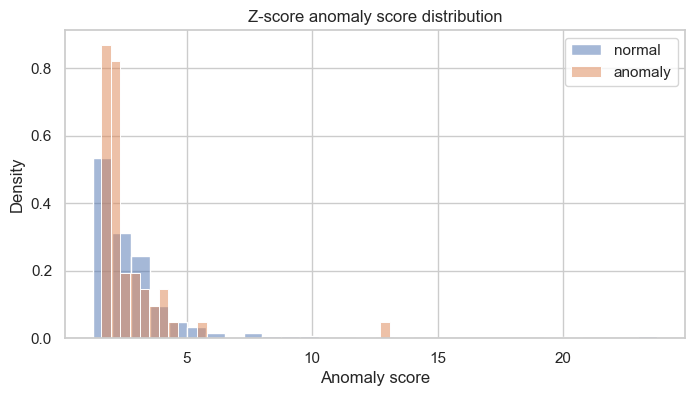

In [11]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=z_df, x="threshold", y="precision", marker="o", label="Precision")
sns.lineplot(data=z_df, x="threshold", y="recall", marker="o", label="Recall")
sns.lineplot(data=z_df, x="threshold", y="f1", marker="o", label="F1")
plt.title("Z-score threshold effect")
plt.ylabel("Score")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(z_score[y_test == 0], bins=30, stat="density", label="normal", alpha=0.5)
sns.histplot(z_score[y_test == 1], bins=30, stat="density", label="anomaly", alpha=0.5)
plt.title("Z-score anomaly score distribution")
plt.xlabel("Anomaly score")
plt.legend()
plt.show()

## Isolation Forest

Isolation Forest isolates observations using random feature splits. Anomalies tend to require fewer splits because they are rare and different. The important hyperparameters include `contamination`, `n_estimators`, and `max_samples`.

`contamination` is an assumption about the expected anomaly proportion. If it is wrong, the detector may produce too many false alarms or miss too many anomalies.

In [12]:
iso_rows = []
iso_score_reference = None

for contamination in [0.01, 0.03, 0.05, 0.10, 0.20]:
    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        max_samples="auto",
        random_state=RANDOM_STATE
    )
    model.fit(X_train_normal_scaled)
    # decision_function is larger for normal points, so multiply by -1 for anomaly score
    scores = -model.decision_function(X_test_scaled)
    pred = (model.predict(X_test_scaled) == -1).astype(int)
    iso_rows.append({
        "contamination": contamination,
        **evaluate_binary(y_test, pred, scores, name="IsolationForest")
    })
    if contamination == 0.10:
        iso_score_reference = scores

iso_df = pd.DataFrame(iso_rows)
iso_df

,contamination,method,precision,recall,f1,ROC_AUC,PR_AUC
0,0.01,IsolationForest,0.000000,0.000000,0.000000,0.665257,0.147616
1,0.03,IsolationForest,0.160000,0.074074,0.101266,0.665257,0.147616
2,0.05,IsolationForest,0.129032,0.074074,0.094118,0.665257,0.147616
3,0.10,IsolationForest,0.148148,0.148148,0.148148,0.665257,0.147616
4,0.20,IsolationForest,0.120370,0.240741,0.160494,0.665257,0.147616


### Contamination as an alert-rate assumption

`contamination` is not a magic model-tuning value; it encodes the approximate fraction of samples that will be flagged. The actual anomaly proportion in the test set may be different from this assumption. The table below makes that mismatch visible by comparing the requested contamination with the achieved flagged rate and the true anomaly rate in the test set.

In [13]:
iso_flag_rate = iso_df.copy()
if "recall" in iso_flag_rate.columns:
    true_anomaly_rate = y_test.mean()
    flag_rate_rows = []
    for contamination in [0.01, 0.03, 0.05, 0.10, 0.20]:
        model = IsolationForest(n_estimators=200, contamination=contamination, random_state=RANDOM_STATE)
        model.fit(X_train_normal_scaled)
        pred = (model.predict(X_test_scaled) == -1).astype(int)
        flag_rate_rows.append({
            "contamination_setting": contamination,
            "test_flagged_rate": pred.mean(),
            "true_anomaly_rate_in_test": true_anomaly_rate,
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred, zero_division=0),
            "f1": f1_score(y_test, pred, zero_division=0)
        })
    flag_rate_df = pd.DataFrame(flag_rate_rows)
    display(flag_rate_df.round(4))

,contamination_setting,test_flagged_rate,true_anomaly_rate_in_test,precision,recall,f1
0,0.01,0.0148,0.1,0.0000,0.0000,0.0000
1,0.03,0.0463,0.1,0.1600,0.0741,0.1013
2,0.05,0.0574,0.1,0.1290,0.0741,0.0941
3,0.10,0.1000,0.1,0.1481,0.1481,0.1481
4,0.20,0.2000,0.1,0.1204,0.2407,0.1605


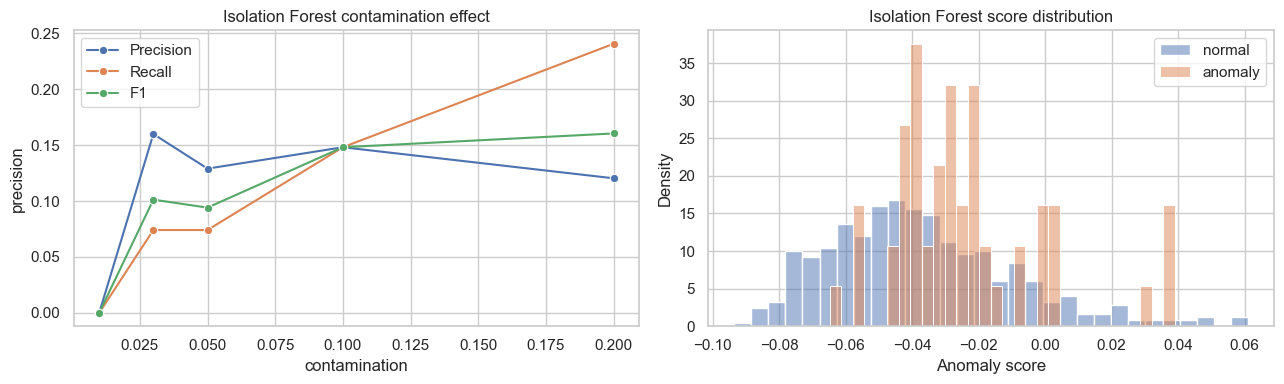

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.lineplot(data=iso_df, x="contamination", y="precision", marker="o", label="Precision", ax=axes[0])
sns.lineplot(data=iso_df, x="contamination", y="recall", marker="o", label="Recall", ax=axes[0])
sns.lineplot(data=iso_df, x="contamination", y="f1", marker="o", label="F1", ax=axes[0])
axes[0].set_title("Isolation Forest contamination effect")

sns.histplot(iso_score_reference[y_test == 0], bins=30, stat="density", label="normal", alpha=0.5, ax=axes[1])
sns.histplot(iso_score_reference[y_test == 1], bins=30, stat="density", label="anomaly", alpha=0.5, ax=axes[1])
axes[1].set_title("Isolation Forest score distribution")
axes[1].set_xlabel("Anomaly score")
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
iso_tree_rows = []
for n_estimators in [50, 100, 200, 400]:
    for max_samples in [64, 128, "auto"]:
        model = IsolationForest(
            n_estimators=n_estimators,
            contamination=0.10,
            max_samples=max_samples,
            random_state=RANDOM_STATE
        )
        model.fit(X_train_normal_scaled)
        scores = -model.decision_function(X_test_scaled)
        pred = (model.predict(X_test_scaled) == -1).astype(int)
        iso_tree_rows.append({
            "n_estimators": n_estimators,
            "max_samples": max_samples,
            **evaluate_binary(y_test, pred, scores, name="IsolationForest")
        })

pd.DataFrame(iso_tree_rows)

,n_estimators,max_samples,method,precision,recall,f1,ROC_AUC,PR_AUC
0,50,64,IsolationForest,0.094340,0.092593,0.093458,0.624943,0.129565
1,50,128,IsolationForest,0.105263,0.111111,0.108108,0.637860,0.144220
2,50,auto,IsolationForest,0.166667,0.185185,0.175439,0.613893,0.129334
3,100,64,IsolationForest,0.086207,0.092593,0.089286,0.638203,0.152725
4,100,128,IsolationForest,0.118644,0.129630,0.123894,0.636755,0.142437
5,100,auto,IsolationForest,0.169811,0.166667,0.168224,0.648529,0.146519
6,200,64,IsolationForest,0.101695,0.111111,0.106195,0.616598,0.135146
7,200,128,IsolationForest,0.096774,0.111111,0.103448,0.631039,0.138369
8,200,auto,IsolationForest,0.148148,0.148148,0.148148,0.665257,0.147616
9,400,64,IsolationForest,0.120690,0.129630,0.125000,0.648643,0.147934


## One-Class SVM

One-Class SVM learns a boundary around normal data. Points outside the boundary are treated as anomalies. With the RBF kernel, the boundary can become flexible, but it is sensitive to scaling, `nu`, and `gamma`.

`nu` roughly controls the fraction of training points allowed outside the learned boundary. `gamma` controls how local or flexible the RBF boundary is.

In [16]:
svm_rows = []
for nu in [0.01, 0.05, 0.10, 0.20]:
    for gamma in ["scale", 0.001, 0.01, 0.1, 1.0]:
        model = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma)
        model.fit(X_train_normal_scaled)
        scores = -model.decision_function(X_test_scaled).ravel()
        pred = (model.predict(X_test_scaled) == -1).astype(int)
        svm_rows.append({
            "nu": nu,
            "gamma": gamma,
            **evaluate_binary(y_test, pred, scores, name="OneClassSVM")
        })

svm_df = pd.DataFrame(svm_rows)
svm_df.sort_values("f1", ascending=False).head(10)

,nu,gamma,method,precision,recall,f1,ROC_AUC,PR_AUC
18,0.20,0.1,OneClassSVM,0.125581,1.000000,0.223140,0.854710,0.293166
13,0.10,0.1,OneClassSVM,0.125581,1.000000,0.223140,0.854633,0.293099
8,0.05,0.1,OneClassSVM,0.125290,1.000000,0.222680,0.854633,0.293073
3,0.01,0.1,OneClassSVM,0.125000,1.000000,0.222222,0.854672,0.293385
19,0.20,1.0,OneClassSVM,0.100000,1.000000,0.181818,0.933566,0.492377
9,0.05,1.0,OneClassSVM,0.100000,1.000000,0.181818,0.933566,0.492316
4,0.01,1.0,OneClassSVM,0.100000,1.000000,0.181818,0.933566,0.492574
14,0.10,1.0,OneClassSVM,0.100000,1.000000,0.181818,0.933566,0.492377
15,0.20,scale,OneClassSVM,0.116279,0.277778,0.163934,0.562109,0.115503
0,0.01,scale,OneClassSVM,0.150000,0.166667,0.157895,0.571483,0.127745


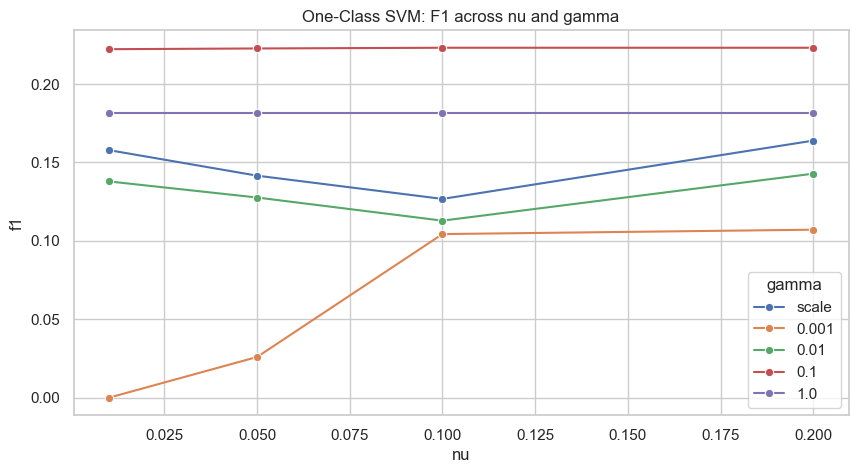

In [17]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=svm_df, x="nu", y="f1", hue="gamma", marker="o")
plt.title("One-Class SVM: F1 across nu and gamma")
plt.show()

## Local Outlier Factor

LOF compares the local density of a point to the density of its neighbors. A point is anomalous if it lies in a much lower-density region than nearby points.

For novelty detection, we use `novelty=True`, fit LOF on normal training data, and then score the mixed test set. Small `n_neighbors` makes LOF very local and noise-sensitive; large values make it more global.

In [18]:
lof_rows = []

for n_neighbors in [5, 10, 20, 35, 50]:
    for contamination in [0.03, 0.05, 0.10, 0.20]:
        model = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            contamination=contamination,
            novelty=True
        )
        model.fit(X_train_normal_scaled)
        scores = -model.decision_function(X_test_scaled)
        pred = (model.predict(X_test_scaled) == -1).astype(int)
        lof_rows.append({
            "n_neighbors": n_neighbors,
            "contamination": contamination,
            **evaluate_binary(y_test, pred, scores, name="LOF")
        })

lof_df = pd.DataFrame(lof_rows)
lof_df.sort_values("f1", ascending=False).head(10)

,n_neighbors,contamination,method,precision,recall,f1,ROC_AUC,PR_AUC
2,5,0.10,LOF,0.380435,0.648148,0.479452,0.890261,0.388230
3,5,0.20,LOF,0.314465,0.925926,0.469484,0.890261,0.388230
6,10,0.10,LOF,0.371795,0.537037,0.439394,0.874638,0.331793
7,10,0.20,LOF,0.292994,0.851852,0.436019,0.874638,0.331793
1,5,0.05,LOF,0.440000,0.407407,0.423077,0.890261,0.388230
11,20,0.20,LOF,0.290780,0.759259,0.420513,0.856310,0.287573
15,35,0.20,LOF,0.272727,0.666667,0.387097,0.829180,0.255193
10,20,0.10,LOF,0.333333,0.444444,0.380952,0.856310,0.287573
5,10,0.05,LOF,0.375000,0.333333,0.352941,0.874638,0.331793
19,50,0.20,LOF,0.248120,0.611111,0.352941,0.805098,0.225192


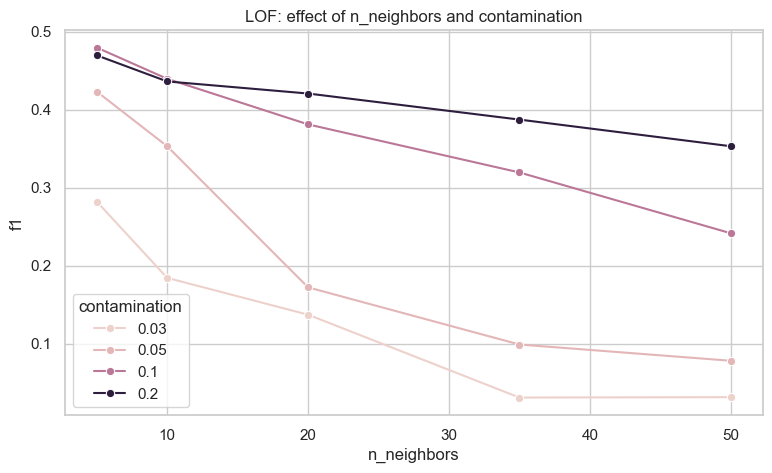

In [19]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=lof_df, x="n_neighbors", y="f1", hue="contamination", marker="o")
plt.title("LOF: effect of n_neighbors and contamination")
plt.show()

## Autoencoder anomaly detection

An autoencoder is trained to reconstruct normal samples. If it learns the structure of normal data, abnormal samples should produce larger reconstruction errors.

This assumption can fail if the autoencoder is too powerful and reconstructs anomalies well. The latent dimension and threshold choice strongly affect results.

The section below runs only if TensorFlow/Keras is available.

In [20]:
# Optional installation if needed:
# !pip install tensorflow

In [21]:
autoencoder_results = []
ae_test_errors_by_latent = {}

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    tf.random.set_seed(RANDOM_STATE)

    X_train_norm_ae, X_val_norm_ae = train_test_split(
        X_train_normal_scaled, test_size=0.20, random_state=RANDOM_STATE
    )

    def build_autoencoder(input_dim, latent_dim):
        inp = keras.Input(shape=(input_dim,))
        x = layers.Dense(32, activation="relu")(inp)
        z = layers.Dense(latent_dim, activation="relu", name="latent")(x)
        x = layers.Dense(32, activation="relu")(z)
        out = layers.Dense(input_dim, activation="linear")(x)
        model = keras.Model(inp, out)
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
        return model

    for latent_dim in [2, 4, 8, 16]:
        ae = build_autoencoder(X_train_normal_scaled.shape[1], latent_dim)
        history = ae.fit(
            X_train_norm_ae, X_train_norm_ae,
            validation_data=(X_val_norm_ae, X_val_norm_ae),
            epochs=80,
            batch_size=64,
            verbose=0,
            callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
        )

        val_rec = ae.predict(X_val_norm_ae, verbose=0)
        val_errors = np.mean((X_val_norm_ae - val_rec) ** 2, axis=1)

        test_rec = ae.predict(X_test_scaled, verbose=0)
        test_errors = np.mean((X_test_scaled - test_rec) ** 2, axis=1)
        ae_test_errors_by_latent[latent_dim] = test_errors

        for percentile in [90, 95, 97.5, 99]:
            threshold = np.percentile(val_errors, percentile)
            pred = (test_errors >= threshold).astype(int)
            autoencoder_results.append({
                "latent_dim": latent_dim,
                "threshold_percentile": percentile,
                "threshold": threshold,
                **evaluate_binary(y_test, pred, test_errors, name="Autoencoder")
            })

    ae_df = pd.DataFrame(autoencoder_results)
    display(ae_df.sort_values("f1", ascending=False).head(12))

except ImportError:
    print("TensorFlow is not installed. The autoencoder section is skipped.")
    ae_df = pd.DataFrame()

,latent_dim,threshold_percentile,threshold,method,precision,recall,f1,ROC_AUC,PR_AUC
12,16,90.0,0.431141,Autoencoder,0.233333,0.259259,0.245614,0.824226,0.246492
8,8,90.0,0.465960,Autoencoder,0.162162,0.222222,0.187500,0.787418,0.209947
13,16,95.0,0.498064,Autoencoder,0.214286,0.166667,0.187500,0.824226,0.246492
4,4,90.0,0.633360,Autoencoder,0.161290,0.185185,0.172414,0.741122,0.178476
9,8,95.0,0.553786,Autoencoder,0.146341,0.111111,0.126316,0.787418,0.209947
10,8,97.5,0.681147,Autoencoder,0.210526,0.074074,0.109589,0.787418,0.209947
5,4,95.0,0.795261,Autoencoder,0.108108,0.074074,0.087912,0.741122,0.178476
14,16,97.5,0.631394,Autoencoder,0.187500,0.055556,0.085714,0.824226,0.246492
0,2,90.0,0.888076,Autoencoder,0.061224,0.055556,0.058252,0.614960,0.122659
6,4,97.5,0.976289,Autoencoder,0.111111,0.037037,0.055556,0.741122,0.178476


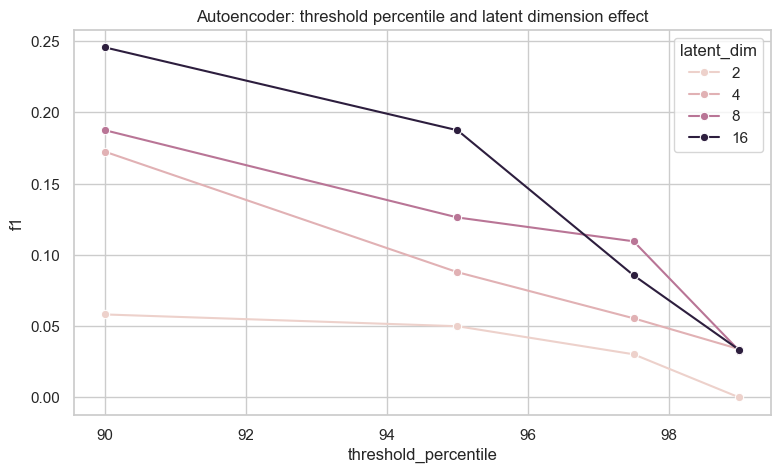

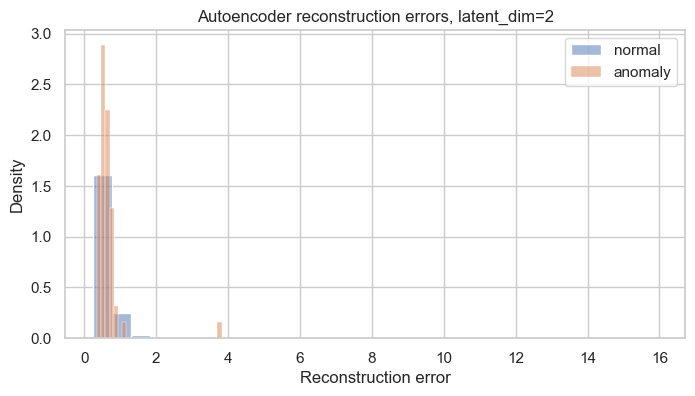

In [22]:
if len(ae_df) > 0:
    plt.figure(figsize=(9, 5))
    sns.lineplot(data=ae_df, x="threshold_percentile", y="f1", hue="latent_dim", marker="o")
    plt.title("Autoencoder: threshold percentile and latent dimension effect")
    plt.show()

    latent_to_plot = sorted(ae_test_errors_by_latent.keys())[0]
    scores = ae_test_errors_by_latent[latent_to_plot]
    plt.figure(figsize=(8, 4))
    sns.histplot(scores[y_test == 0], bins=30, stat="density", label="normal", alpha=0.5)
    sns.histplot(scores[y_test == 1], bins=30, stat="density", label="anomaly", alpha=0.5)
    plt.title(f"Autoencoder reconstruction errors, latent_dim={latent_to_plot}")
    plt.xlabel("Reconstruction error")
    plt.legend()
    plt.show()

## Threshold selection

A detector usually gives a continuous anomaly score. The threshold determines the practical behavior. If missing anomalies is very costly, one may choose a low threshold and accept more false alarms. If investigations are expensive, one may require high precision.

Precision-recall curves and recall at fixed precision are often more useful than accuracy.

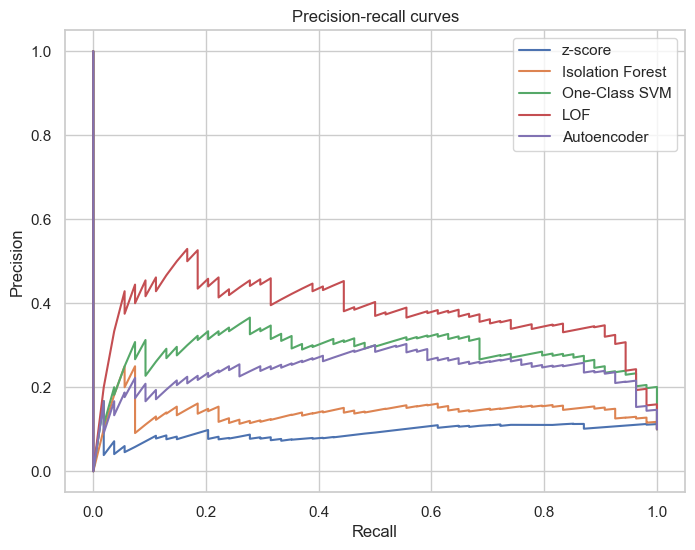

,method,PR_AUC,ROC_AUC,recall_at_precision_0.80,precision_at_top_25,precision_at_top_50
3,LOF,0.388230,0.890261,0.0,0.44,0.44
2,One-Class SVM,0.293166,0.854710,0.0,0.28,0.34
4,Autoencoder,0.246492,0.824226,0.0,0.20,0.24
1,Isolation Forest,0.147616,0.665257,0.0,0.16,0.14
0,z-score,0.097937,0.494627,0.0,0.04,0.06


In [23]:
score_sets = {
    "z-score": z_score,
    "Isolation Forest": iso_score_reference
}

best_svm = svm_df.sort_values("f1", ascending=False).iloc[0]
svm_best_model = OneClassSVM(kernel="rbf", nu=float(best_svm["nu"]), gamma=best_svm["gamma"])
svm_best_model.fit(X_train_normal_scaled)
score_sets["One-Class SVM"] = -svm_best_model.decision_function(X_test_scaled).ravel()

best_lof = lof_df.sort_values("f1", ascending=False).iloc[0]
lof_best_model = LocalOutlierFactor(
    n_neighbors=int(best_lof["n_neighbors"]),
    contamination=float(best_lof["contamination"]),
    novelty=True
)
lof_best_model.fit(X_train_normal_scaled)
score_sets["LOF"] = -lof_best_model.decision_function(X_test_scaled)

if len(ae_df) > 0:
    best_ae = ae_df.sort_values("f1", ascending=False).iloc[0]
    score_sets["Autoencoder"] = ae_test_errors_by_latent[int(best_ae["latent_dim"])]

plt.figure(figsize=(8, 6))
threshold_summary = []

for name, scores in score_sets.items():
    precision, recall, thresholds = precision_recall_curve(y_test, scores)
    plt.plot(recall, precision, label=name)
    threshold_summary.append({
        "method": name,
        "PR_AUC": average_precision_score(y_test, scores),
        "ROC_AUC": roc_auc_score(y_test, scores),
        "recall_at_precision_0.80": recall_at_fixed_precision(y_test, scores, 0.80),
        "precision_at_top_25": precision_at_k(y_test, scores, 25),
        "precision_at_top_50": precision_at_k(y_test, scores, 50)
    })

plt.title("Precision-recall curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

pd.DataFrame(threshold_summary).sort_values("PR_AUC", ascending=False)

### Precision and recall under fixed investigation budgets

In practice, anomaly detection often begins with a limited alert budget: for example, an analyst may inspect only the top 10, 25, or 50 most suspicious cases. This experiment evaluates detectors by ranking scores instead of using each algorithm's default threshold. It is especially useful when the cost is driven by the number of cases a human can review.

top_k_budget,10,25,50,100
method,,,,
Autoencoder,0.1,0.20,0.24,0.30
Isolation Forest,0.1,0.16,0.14,0.12
LOF,0.4,0.44,0.44,0.37
One-Class SVM,0.2,0.28,0.34,0.32
z-score,0.1,0.04,0.06,0.08


top_k_budget,10,25,50,100
method,,,,
Autoencoder,0.019,0.093,0.222,0.556
Isolation Forest,0.019,0.074,0.130,0.222
LOF,0.074,0.204,0.407,0.685
One-Class SVM,0.037,0.130,0.315,0.593
z-score,0.019,0.019,0.056,0.148


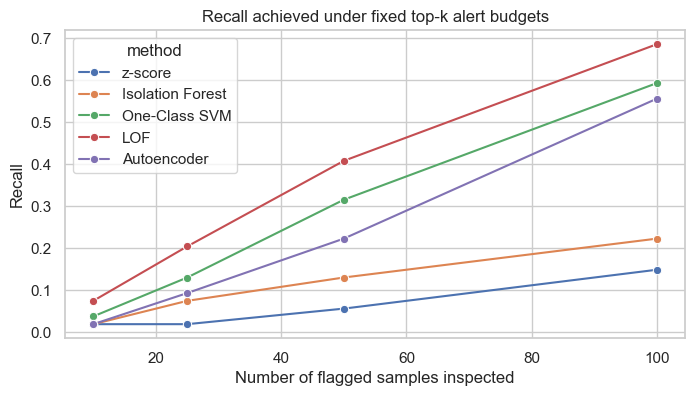

In [24]:
budget_rows = []
for name, scores in score_sets.items():
    order = np.argsort(scores)[::-1]
    for k in [10, 25, 50, 100]:
        selected = order[:k]
        pred_budget = np.zeros_like(y_test)
        pred_budget[selected] = 1
        budget_rows.append({
            "method": name,
            "top_k_budget": k,
            "precision_at_k": precision_score(y_test, pred_budget, zero_division=0),
            "recall_at_k": recall_score(y_test, pred_budget, zero_division=0),
            "f1_at_k": f1_score(y_test, pred_budget, zero_division=0),
            "anomalies_found": int(y_test[selected].sum())
        })

budget_df = pd.DataFrame(budget_rows)
display(budget_df.pivot(index="method", columns="top_k_budget", values="precision_at_k").round(3))
display(budget_df.pivot(index="method", columns="top_k_budget", values="recall_at_k").round(3))

plt.figure(figsize=(8, 4))
sns.lineplot(data=budget_df, x="top_k_budget", y="recall_at_k", hue="method", marker="o")
plt.title("Recall achieved under fixed top-k alert budgets")
plt.xlabel("Number of flagged samples inspected")
plt.ylabel("Recall")
plt.show()

## Model comparison

The following table uses representative thresholds from each method. It should be read as a practical comparison, not as a universal ranking. A different application may prefer higher recall or higher precision.

### Supervised rare-event reference model

This notebook is about anomaly detection, not ordinary supervised classification. Still, a small supervised baseline helps clarify the difference. Here a logistic regression model is trained with the binary anomaly labels. It is not directly comparable to novelty detection because it uses labeled anomalies during training, but it shows what changes when labeled rare events are available.

In [26]:
from sklearn.linear_model import LogisticRegression

supervised_clf = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)
supervised_clf.fit(X_train_all_scaled, y_train_all)
supervised_scores = supervised_clf.predict_proba(X_test_scaled)[:, 1]
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, supervised_scores)
f1_lr = 2 * precision_lr[:-1] * recall_lr[:-1] / (precision_lr[:-1] + recall_lr[:-1] + 1e-12)
best_idx = np.argmax(f1_lr)
supervised_threshold = thresholds_lr[best_idx]
supervised_pred = (supervised_scores >= supervised_threshold).astype(int)

supervised_metrics = evaluate_binary(y_test, supervised_pred, supervised_scores, name="Supervised Logistic Regression")

supervised_metrics = evaluate_binary(
    y_test,
    supervised_pred,
    supervised_scores,
    name="Supervised Logistic Regression"
)

supervised_df = pd.DataFrame([supervised_metrics])
numeric_cols = supervised_df.select_dtypes(include="number").columns
supervised_df[numeric_cols] = supervised_df[numeric_cols].round(4)

display(supervised_df)

,method,precision,recall,f1,ROC_AUC,PR_AUC
0,Supervised Logistic Regression,0.9787,0.8519,0.9109,0.9942,0.9647


Interpretation: this model is allowed to learn from anomaly labels, so it answers a different question than novelty detection models trained only on normal samples.

In [27]:
comparison_rows = []

# z-score: choose best F1 among tested thresholds
best_z = z_df.sort_values("f1", ascending=False).iloc[0]
comparison_rows.append(best_z.to_dict())

# Isolation Forest: choose best F1 among contamination settings
best_iso = iso_df.sort_values("f1", ascending=False).iloc[0]
comparison_rows.append(best_iso.to_dict())

comparison_rows.append(best_svm.to_dict())
comparison_rows.append(best_lof.to_dict())

if len(ae_df) > 0:
    comparison_rows.append(best_ae.to_dict())

comparison_df = pd.DataFrame(comparison_rows)
cols = [c for c in ["method", "precision", "recall", "f1", "ROC_AUC", "PR_AUC"] if c in comparison_df.columns]
comparison_df[cols].sort_values("f1", ascending=False)

,method,precision,recall,f1,ROC_AUC,PR_AUC
3,LOF,0.380435,0.648148,0.479452,0.890261,0.388230
4,Autoencoder,0.233333,0.259259,0.245614,0.824226,0.246492
2,OneClassSVM,0.125581,1.000000,0.223140,0.854710,0.293166
0,z-score,0.107784,0.666667,0.185567,0.494627,0.097937
1,IsolationForest,0.120370,0.240741,0.160494,0.665257,0.147616


## Error analysis

False negatives are anomalies that the detector did not flag. False positives are normal samples that look unusual under the detector’s definition of normality. In anomaly detection, both are informative: false negatives may be anomalies that resemble normal cases, while false positives may be rare-but-valid normal patterns.

,pred_normal,pred_anomaly
true_normal,456,30
true_anomaly,30,24


Error analysis method: LOF
Top-10% threshold: 0.08940483216965012


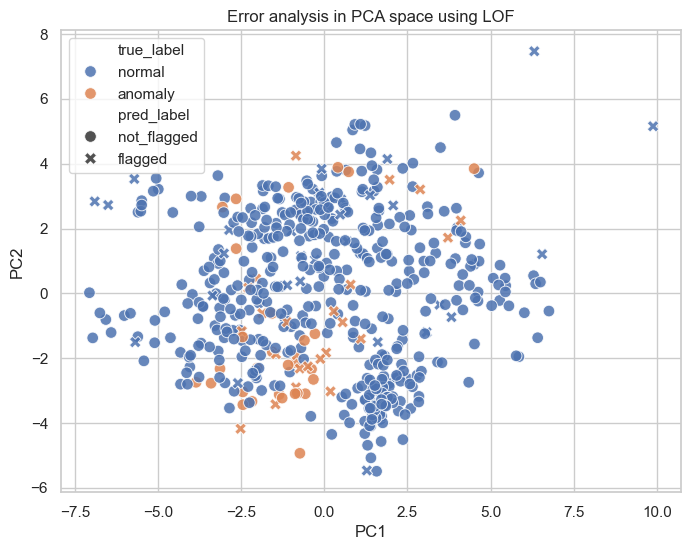

In [28]:
# Use the strongest representative score by PR-AUC from threshold_summary.
score_table = pd.DataFrame(threshold_summary).sort_values("PR_AUC", ascending=False)
best_score_name = score_table.iloc[0]["method"]
best_scores = score_sets[best_score_name]

# Flag the top 10% most suspicious samples for visual error analysis.
pred_top10, threshold_top10 = predict_by_top_fraction(best_scores, 0.10)

cm = confusion_matrix(y_test, pred_top10)
display(pd.DataFrame(cm, index=["true_normal", "true_anomaly"], columns=["pred_normal", "pred_anomaly"]))
print("Error analysis method:", best_score_name)
print("Top-10% threshold:", threshold_top10)

analysis_df = pd.DataFrame(X_test_pca, columns=["PC1", "PC2"])
analysis_df["true_label"] = np.where(y_test == 1, "anomaly", "normal")
analysis_df["pred_label"] = np.where(pred_top10 == 1, "flagged", "not_flagged")
analysis_df["score"] = best_scores

plt.figure(figsize=(8, 6))
sns.scatterplot(data=analysis_df, x="PC1", y="PC2", hue="true_label", style="pred_label", s=70, alpha=0.85)
plt.title(f"Error analysis in PCA space using {best_score_name}")
plt.show()

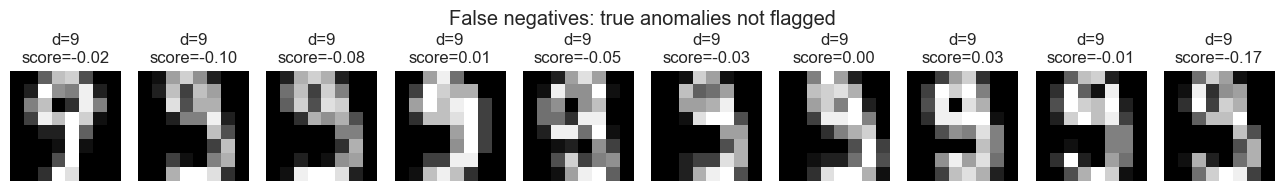

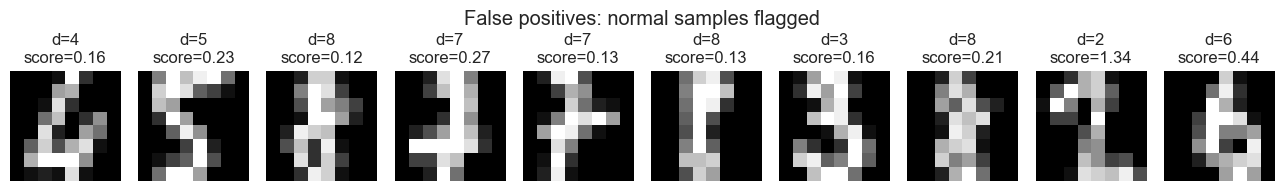

In [29]:
false_negatives = np.where((y_test == 1) & (pred_top10 == 0))[0]
false_positives = np.where((y_test == 0) & (pred_top10 == 1))[0]

def show_digit_indices(indices, title, max_images=10):
    indices = indices[:max_images]
    if len(indices) == 0:
        print(f"No samples to show for: {title}")
        return
    fig, axes = plt.subplots(1, len(indices), figsize=(1.3 * len(indices), 2))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        ax.imshow(X_test[idx].reshape(8, 8), cmap="gray")
        ax.set_title(f"d={digit_test[idx]}\nscore={best_scores[idx]:.2f}")
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_digit_indices(false_negatives, "False negatives: true anomalies not flagged")
show_digit_indices(false_positives, "False positives: normal samples flagged")

## Outlier detection vs novelty detection vs supervised rare-event classification

- **Outlier detection**: the training data may already contain anomalies, and the model tries to identify unusual points within that dataset.
- **Novelty detection**: the training data is assumed mostly normal, and anomalies appear later during testing or deployment.
- **Supervised rare-event classification**: labeled anomalies are available during training, but the class imbalance is severe.

This notebook mainly uses novelty detection because the models are fitted on normal training samples.

## Limitations

This is a controlled anomaly setup, not real fraud or network intrusion data. Real anomalies may be more diverse, more subtle, and more expensive to label. Threshold selection usually requires domain-specific costs. Unsupervised anomaly scores do not guarantee semantic abnormality. High-dimensional distances can be unreliable. Autoencoder performance depends strongly on architecture and training setup.

## What we learned

Anomaly detection is threshold-dependent. Accuracy is usually misleading. Different algorithms define abnormality differently: extreme features, isolation, boundary violation, local density drop, or reconstruction error. Hyperparameters strongly affect false alarms and missed anomalies.

## Possible extensions

Extensions include real credit card fraud data, network intrusion detection, time-series anomaly detection, variational autoencoder anomaly detection, Isolation Forest explanations, conformal anomaly detection, and cost-sensitive anomaly detection.